<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/26_Session_K_Means_Clustering_with_Codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


K-Means clustering is the most popular unsupervised learning algorithm. It is used when we have unlabelled data which is data without defined categories or groups.

 The algorithm follows an easy or simple way to classify a given data set through a certain number of clusters, fixed apriori.

 K-Means algorithm works iteratively to assign each data point to one of K groups based on the features that are provided. Data points are clustered based on feature similarity.

K-Means clustering can be represented diagrammatically as follows:-

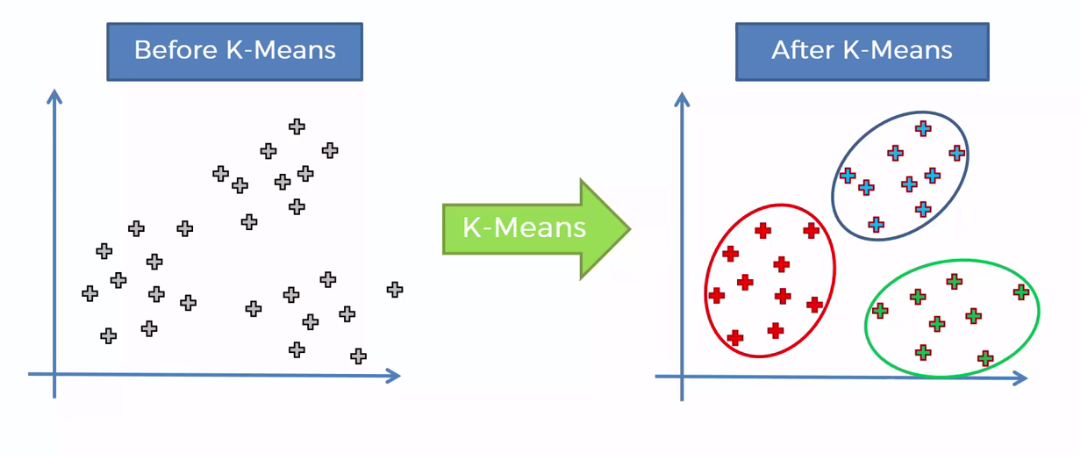



K-Means clustering is the most common unsupervised machine learning algorithm. It is widely used for many applications which include-

Image segmentation

Customer segmentation

Species clustering

Anomaly detection

Clustering languages



**Kmeans Ideology**

K-Means clustering is used to find intrinsic groups within the unlabelled dataset and draw inferences from them. It is based on centroid-based clustering.

**Centroid** - A centroid is a data point at the centre of a cluster. In centroid-based clustering, clusters are represented by a centroid. It is an iterative algorithm in which the notion of similarity is derived by how close a data point is to the centroid of the cluster. K-Means clustering works as follows:- The K-Means clustering algorithm uses an iterative procedure to deliver a final result. The algorithm requires number of clusters K and the data set as input. The data set is a collection of features for each data point. The algorithm starts with initial estimates for the K centroids. The algorithm then iterates between two steps:-

**3.1 Data assignment step**
Each centroid defines one of the clusters. In this step, each data point is assigned to its nearest centroid, which is based on the squared Euclidean distance. So, if ci is the collection of centroids in set C, then each data point is assigned to a cluster based on minimum Euclidean distance.

**3.2 Centroid update step**
In this step, the centroids are recomputed and updated. This is done by taking the mean of all data points assigned to that centroid’s cluster.

The algorithm then iterates between step 1 and step 2 until a stopping criteria is met. Stopping criteria means no data points change the clusters, the sum of the distances is minimized or some maximum number of iterations is reached. This algorithm is guaranteed to converge to a result. The result may be a local optimum meaning that assessing more than one run of the algorithm with randomized starting centroids may give a better outcome.

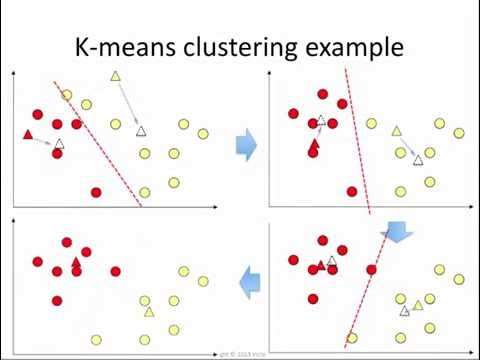



**Choosing the value of K**

The K-Means algorithm depends upon finding the number of clusters and data labels for a pre-defined value of K.
To find the number of clusters in the data, we need to run the K-Means clustering algorithm for different values of K and compare the results.

So, the performance of K-Means algorithm depends upon the value of K. We should choose the optimal value of K that gives us best performance. There are different techniques available to find the optimal value of K. The most common technique is the elbow method which is described below.

**Elbow Method**

The elbow method is used to determine the optimal number of clusters in K-means clustering. The elbow method plots the value of the cost function produced by different values of K. The below diagram shows how the elbow method works:-

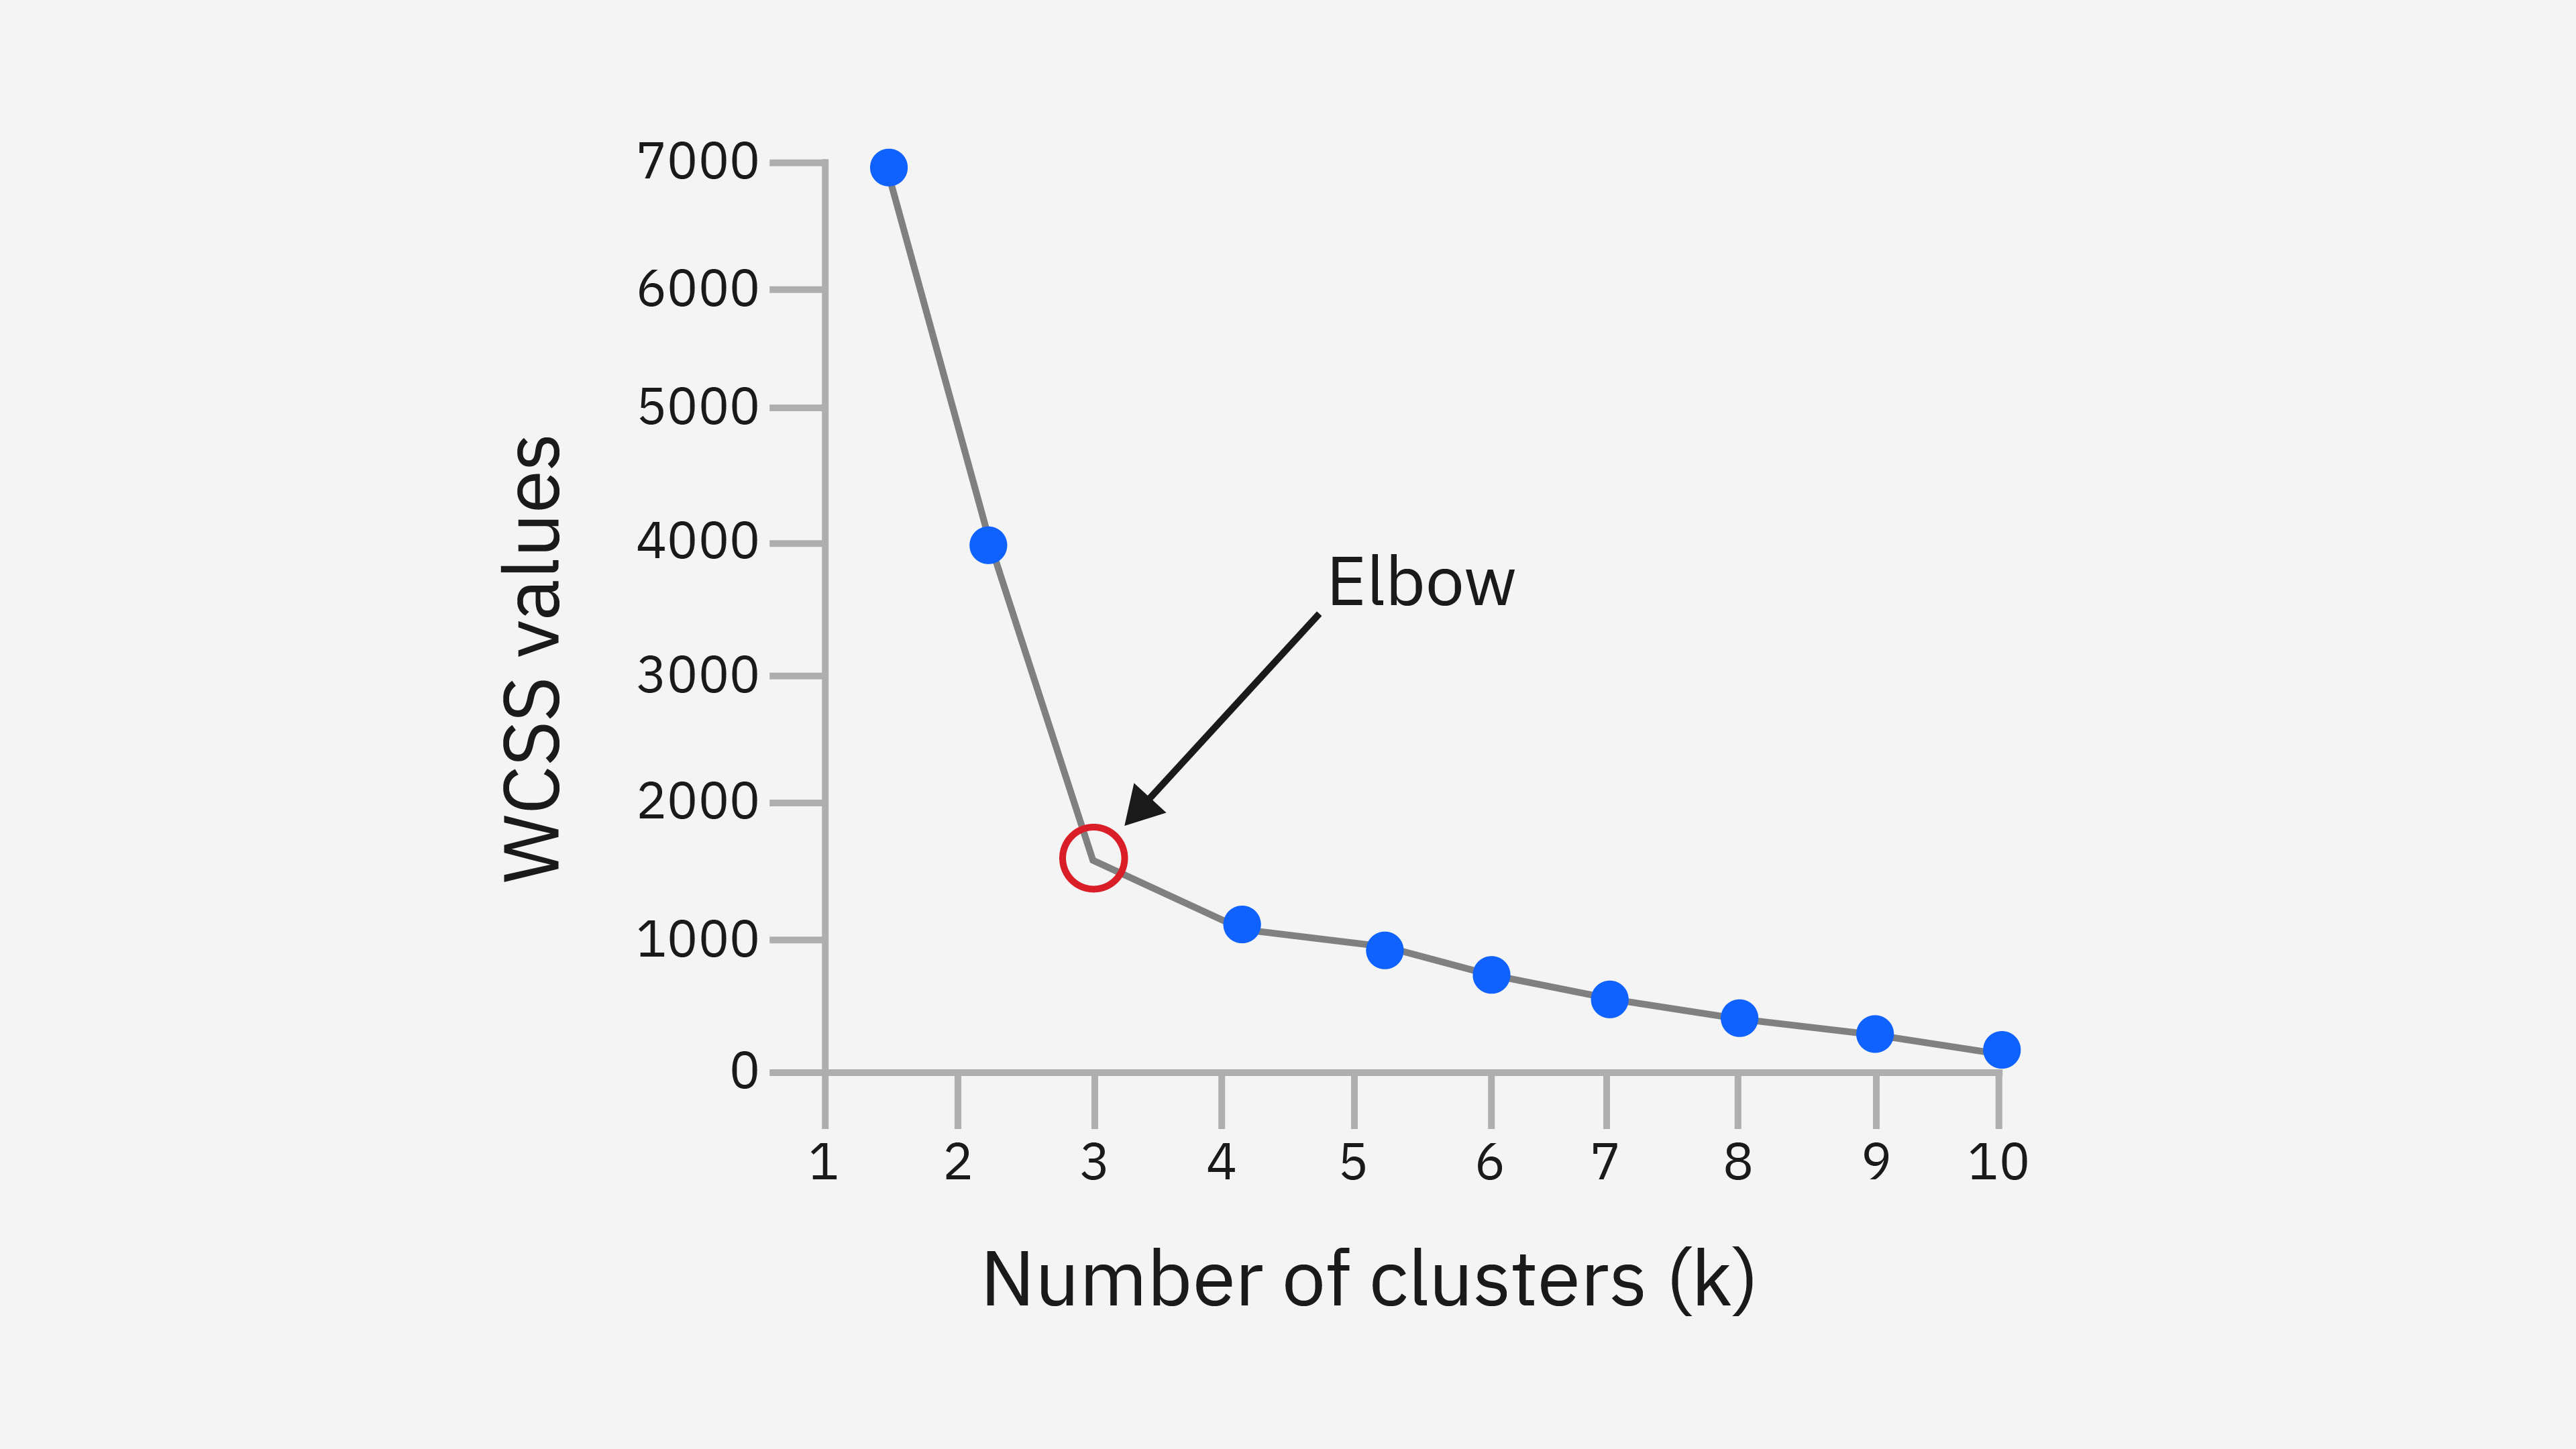

The **Within-Cluster Sum of Squares (WCSS)**, also known as inertia, is a measure of how spread out the data points are within each cluster. The goal of K-Means clustering is to minimize this value.

The formula for WCSS is:

$$ \text{WCSS} = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2 $$

Where:
- $K$ is the number of clusters.
- $C_i$ is the $i$-th cluster.
- $x$ is a data point belonging to cluster $C_i$.
- $\mu_i$ is the centroid (mean) of cluster $C_i$.
- $\|x - \mu_i\|^2$ is the squared Euclidean distance between the data point $x$ and its cluster centroid $\mu_i$.

In simpler terms:
1. For each data point, calculate the squared distance between that point and the centroid of the cluster it belongs to.
2. Sum these squared distances for all data points within a cluster.
3. Sum the results from step 2 for all clusters.

A smaller WCSS value generally indicates that the data points within each cluster are closer to their respective centroids, suggesting a more compact and better-defined cluster structure.

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/Live.csv')
print(df.head())
print(df.shape)

                          status_id status_type status_published  \
0  246675545449582_1649696485147474       video   4/22/2018 6:00   
1  246675545449582_1649426988507757       photo  4/21/2018 22:45   
2  246675545449582_1648730588577397       video   4/21/2018 6:17   
3  246675545449582_1648576705259452       photo   4/21/2018 2:29   
4  246675545449582_1645700502213739       photo   4/18/2018 3:22   

   num_reactions  num_comments  num_shares  num_likes  num_loves  num_wows  \
0            529           512         262        432         92         3   
1            150             0           0        150          0         0   
2            227           236          57        204         21         1   
3            111             0           0        111          0         0   
4            213             0           0        204          9         0   

   num_hahas  num_sads  num_angrys  Column1  Column2  Column3  Column4  
0          1         1           0      NaN      

In [ ]:
#SUmmary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

In [ ]:
#Checking for missing value
df.isnull().sum()


,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


In [ ]:
df.isna().sum()

,0
status_type,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0
num_sads,0
num_angrys,0


In [ ]:
df.columns

Index(['status_type', 'num_reactions', 'num_comments', 'num_shares',
       'num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads',
       'num_angrys'],
      dtype='object')

In [ ]:
#Stat Summary

df.describe()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


There are 3 categorical variables in the dataset. we will explore them one by one.

In [ ]:
# view the labels in the variable

df['status_id'].unique()

array(['246675545449582_1649696485147474',
       '246675545449582_1649426988507757',
       '246675545449582_1648730588577397', ...,
       '1050855161656896_1060126464063099',
       '1050855161656896_1058663487542730',
       '1050855161656896_1050858841656528'], dtype=object)

In [ ]:
# view how many different types of variables are there

len(df['status_id'].unique())

6997

We can see that there are 6997 unique labels in the status_id variable. The total number of instances in the dataset is 7050. So, it is approximately a unique identifier for each of the instances. Thus this is not a variable that we can use. Lets dropit.

In [ ]:
# view the labels in the variable

df['status_published'].unique()

array(['4/22/2018 6:00', '4/21/2018 22:45', '4/21/2018 6:17', ...,
       '9/21/2016 23:03', '9/20/2016 0:43', '9/10/2016 10:30'],
      dtype=object)

In [ ]:
# view how many different types of variables are there

len(df['status_published'].unique())

6913

Again, we can see that there are 6913 unique labels in the status_published variable. The total number of instances in the dataset is 7050. So, it is also a approximately a unique identifier for each of the instances. Thus this is not a variable that we can use. Lets drop it


In [ ]:
# view the labels in the variable

df['status_type'].unique()



array([3, 1, 0, 2])

In [ ]:
# view how many different types of variables are there

len(df['status_type'].unique())

4

In [ ]:
df.drop(['status_id', 'status_published'], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


**Declaring Feature Vector**

In [ ]:
X = df

y = df['status_type']

**Convert categorical variable into integers**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X['status_type'] = le.fit_transform(X['status_type'])

y = le.transform(y)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   status_type    7050 non-null   int64
 1   num_reactions  7050 non-null   int64
 2   num_comments   7050 non-null   int64
 3   num_shares     7050 non-null   int64
 4   num_likes      7050 non-null   int64
 5   num_loves      7050 non-null   int64
 6   num_wows       7050 non-null   int64
 7   num_hahas      7050 non-null   int64
 8   num_sads       7050 non-null   int64
 9   num_angrys     7050 non-null   int64
dtypes: int64(10)
memory usage: 550.9 KB


**Feature Scaling**

In [ ]:
cols = X.columns

In [ ]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X = ms.fit_transform(X)

In [ ]:
X = pd.DataFrame(X, columns=[cols])

In [ ]:
X.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1.000000,0.112314,0.024393,0.076519,0.091720,0.140030,0.010791,0.006369,0.019608,0.0
1,0.333333,0.031847,0.000000,0.000000,0.031847,0.000000,0.000000,0.000000,0.000000,0.0
2,1.000000,0.048195,0.011243,0.016647,0.043312,0.031963,0.003597,0.006369,0.000000,0.0
3,0.333333,0.023567,0.000000,0.000000,0.023567,0.000000,0.000000,0.000000,0.000000,0.0
4,0.333333,0.045223,0.000000,0.000000,0.043312,0.013699,0.000000,0.000000,0.000000,0.0


**K-Means model with two clusters**

The KMeans algorithm clusters data by trying to separate samples in n groups of equal variances, minimizing a criterion known as inertia, or within-cluster sum-of-squares Inertia, or the within-cluster sum of squares criterion, can be recognized as a measure of how internally coherent clusters are.

The k-means algorithm divides a set of N samples X into K disjoint clusters C, each described by the mean j of the samples in the cluster. The means are commonly called the cluster centroids.

The K-means algorithm aims to choose centroids that minimize the inertia, or within-cluster sum of squared criterion.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)

kmeans.fit(X)

KMeans(n_clusters=2, random_state=0)

K-Means model parameters study

In [ ]:
kmeans.cluster_centers_


array([[9.54921576e-01, 6.46330441e-02, 2.67028654e-02, 2.93171709e-02,
        5.71231462e-02, 4.71007076e-02, 8.18581889e-03, 9.65207685e-03,
        8.04219428e-03, 7.19501847e-03],
       [3.28506857e-01, 3.90710874e-02, 7.54854864e-04, 7.53667113e-04,
        3.85438884e-02, 2.17448568e-03, 2.43721364e-03, 1.20039760e-03,
        2.75348016e-03, 1.45313276e-03]])

Inertia
Inertia is not a normalized metric.

The lower values of inertia are better and zero is optimal.

But in very high-dimensional spaces, euclidean distances tend to become inflated (this is an instance of curse of dimensionality).

Running a dimensionality reduction algorithm such as PCA prior to k-means clustering can alleviate this problem and speed up the computations.

We can calculate model inertia as follows:-

In [ ]:
kmeans.inertia_


237.7572640441955

The lesser the model inertia, the better the model fit.

We can see that the model has very high inertia. So, this is not a good model fit to the data.

**Check quality of weak classification by the model**

In [ ]:
labels = kmeans.labels_

# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

Result: 4288 out of 7050 samples were correctly labeled.


In [ ]:
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Accuracy score: 0.61


**Use elbow method to find optimal number of clusters**

Text(0, 0.5, 'CS')

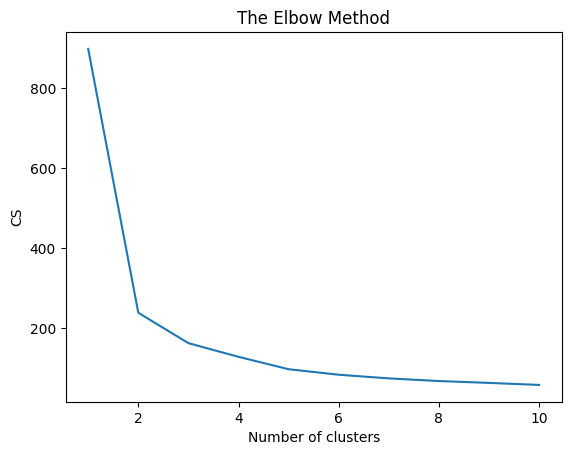

In [ ]:
from sklearn.cluster import KMeans
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2,random_state=0)

kmeans.fit(X)

labels = kmeans.labels_

# check how many of the samples were correctly labeled

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 4288 out of 7050 samples were correctly labeled.
Accuracy score: 0.61


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)

kmeans.fit(X)

# check how many of the samples were correctly labeled
labels = kmeans.labels_

correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 4066 out of 7050 samples were correctly labeled.
Accuracy score: 0.58


In [ ]:
kmeans = KMeans(n_clusters=10, random_state=0)

kmeans.fit(X)

# check how many of the samples were correctly labeled
labels = kmeans.labels_

correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 4009 out of 7050 samples were correctly labeled.
Accuracy score: 0.57


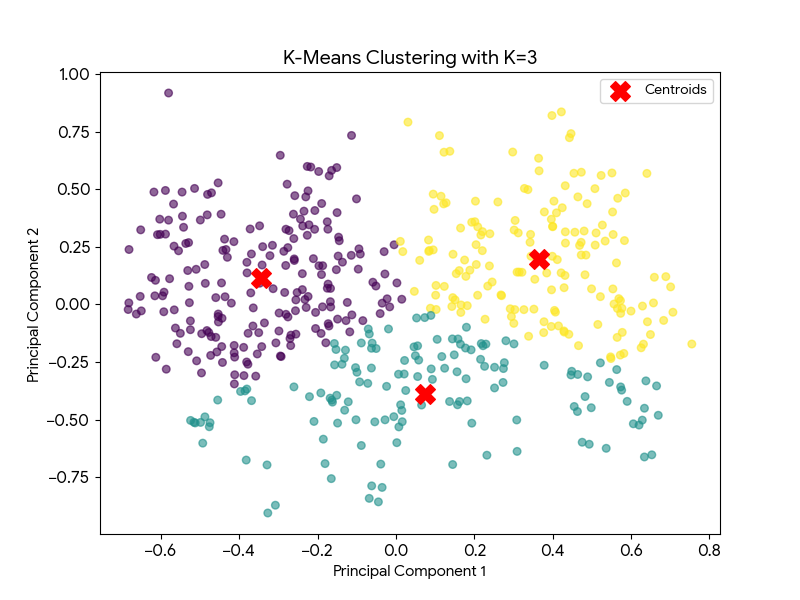

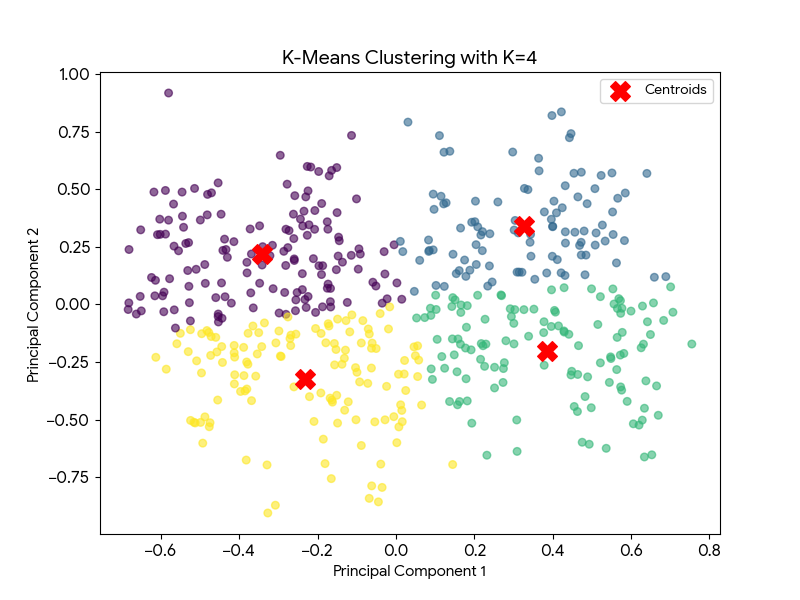

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score


In [ ]:
dfs = pd.read_csv('/content/Mall_Customers.csv')

print('--- Initial Dataset Info ---')
print(dfs.head())
print('Shape :', dfs.shape)

--- Initial Dataset Info ---
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Shape : (200, 5)


In [ ]:
# Remove duplicates
dfs.drop_duplicates(inplace=True)

# Check missing values
print('\n Missing values after cleaning:\n', dfs.isnull().sum())


 Missing values after cleaning:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
dfs.rename(columns={'Genre':'Gender'},inplace=True)
print(dfs.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
dfs['Gender'] = dfs['Gender'].map({'Male':0,'Female': 1})

In [ ]:
dfs.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [ ]:
# Selecting features Clustering

X = dfs[['Gender','Age','Annual Income (k$)','Spending Score (1-100)']]

# Feature Scaling (Crucial for K-means due to Euclidean distance Calculation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.12815215 -1.42456879 -1.73899919 -0.43480148]
 [-1.12815215 -1.28103541 -1.73899919  1.19570407]
 [ 0.88640526 -1.3528021  -1.70082976 -1.71591298]
 [ 0.88640526 -1.13750203 -1.70082976  1.04041783]
 [ 0.88640526 -0.56336851 -1.66266033 -0.39597992]
 [ 0.88640526 -1.20926872 -1.66266033  1.00159627]
 [ 0.88640526 -0.27630176 -1.62449091 -1.71591298]
 [ 0.88640526 -1.13750203 -1.62449091  1.70038436]
 [-1.12815215  1.80493225 -1.58632148 -1.83237767]
 [ 0.88640526 -0.6351352  -1.58632148  0.84631002]
 [-1.12815215  2.02023231 -1.58632148 -1.4053405 ]
 [ 0.88640526 -0.27630176 -1.58632148  1.89449216]
 [ 0.88640526  1.37433211 -1.54815205 -1.36651894]
 [ 0.88640526 -1.06573534 -1.54815205  1.04041783]
 [-1.12815215 -0.13276838 -1.54815205 -1.44416206]
 [-1.12815215 -1.20926872 -1.54815205  1.11806095]
 [ 0.88640526 -0.27630176 -1.50998262 -0.59008772]
 [-1.12815215 -1.3528021  -1.50998262  0.61338066]
 [-1.12815215  0.94373197 -1.43364376 -0.82301709]
 [ 0.88640526 -0.27630176 -1.43

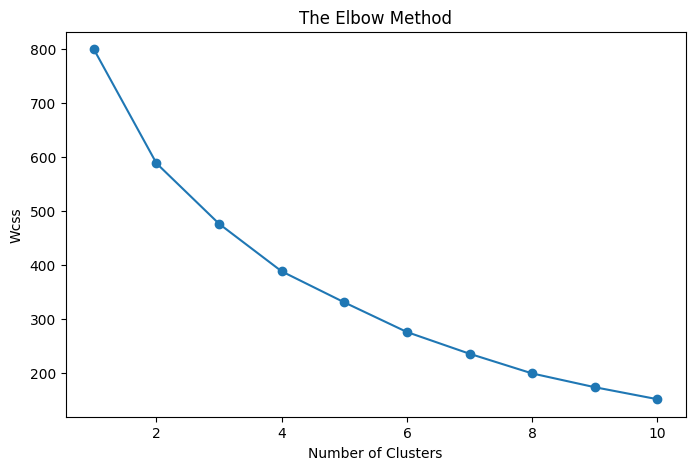

In [ ]:
from sklearn.cluster import KMeans

# Step 5 : Find optimal Number of Clusters (Elbow Method)

wcss = []

for i in range(1,11):
  model = KMeans(n_clusters=i, random_state=42,n_init=10)
  model.fit(X_scaled)
  wcss.append(model.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Wcss')
plt.show()

In [ ]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k,init='k-means++',n_init=20,max_iter=500,random_state=42)

# Fit model and predict cluster labels
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
print(clusters)


[1 1 0 4 0 4 0 4 2 4 2 4 0 4 2 1 0 1 2 4 2 1 0 1 0 1 0 1 0 4 2 4 2 1 0 4 0
 4 0 4 0 1 2 4 0 4 0 4 4 4 0 1 4 2 0 2 0 2 4 2 2 1 0 0 2 1 0 0 1 4 2 0 0 0
 2 1 0 1 4 0 2 1 2 0 4 2 0 4 4 0 0 1 2 0 4 1 0 4 2 1 4 0 2 1 2 4 0 2 2 2 2
 4 0 1 4 4 0 0 0 0 1 0 4 1 4 4 3 1 2 1 3 1 4 4 3 4 0 1 3 4 0 1 4 4 3 1 3 4
 0 1 3 1 0 4 0 4 3 4 3 4 0 4 3 4 3 4 3 4 3 1 3 1 3 1 0 4 3 1 3 1 3 4 3 4 3
 1 3 1 3 4 3 4 3 4 3 4 3 3 3 3]


In [ ]:
# Add cluster column back to original dataframe
dfs['Cluster'] = clusters

print('\n--- Dataset with Cluster Labels ---')
print(dfs.head())


--- Dataset with Cluster Labels ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       0   19                  15                      39   
1           2       0   21                  15                      81   
2           3       1   20                  16                       6   
3           4       1   23                  16                      77   
4           5       1   31                  17                      40   

   Cluster  
0        1  
1        1  
2        0  
3        4  
4        0  


In [ ]:
print('\n--- Cluster Centroids ---')
print(kmeans.cluster_centers_)


--- Cluster Centroids ---
[[ 0.88640526  0.71348051 -0.39034603 -0.53589929]
 [-1.12815215 -0.74922584 -0.08890541  0.79653879]
 [-1.12815215  1.31794399 -0.52575662 -0.44589335]
 [-0.57241217  0.00334086  1.28296665 -1.10146138]
 [ 0.88640526 -0.75047453 -0.00501655  0.6979562 ]]


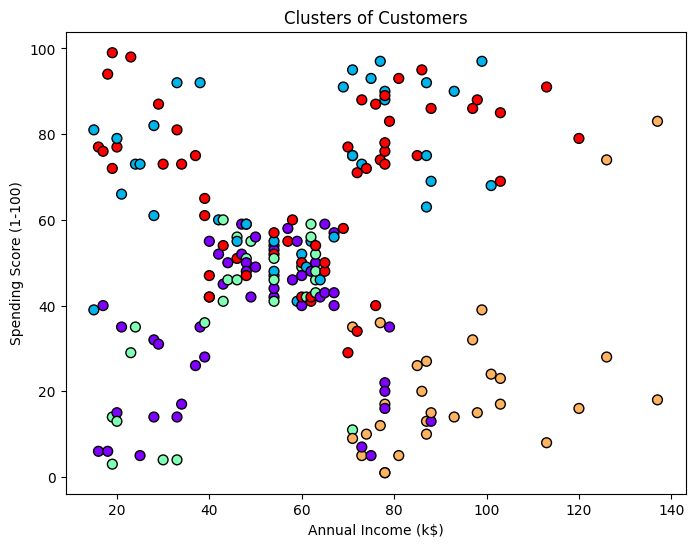

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(dfs['Annual Income (k$)'],dfs['Spending Score (1-100)'],c=dfs['Cluster'],cmap='rainbow',s=50,edgecolors='k')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
score = silhouette_score(X_scaled,clusters)
print(f'\nSilhouette Score: {score:.4f}')


Silhouette Score: 0.3144


In [ ]:
new_customer = np.array(([1,23,16,77]))

#Scale the new customer using the same scaler object
new_customer_scaled = scaler.transform(new_customer.reshape(1, -1))

#Predict the cluster
new_customer_cluster = kmeans.predict(new_customer_scaled)
print(f'\nNew Customer Assigned cluster : {new_customer_cluster}')


New Customer Assigned cluster : [4]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### **What is Agglomerative Clustering ?**

In k-means, we decide the value before hand (like k=5), but in Agglomerative Clustering, it is not at all necessary to know the K-value in advance

this is a Bottom-up approach : Each data point starts as its own individual cluster.then, the data points that are closet to each other merge together to form a larger cluster. This process continues until everything merges together into a single root cluster.

In [ ]:
agg_clustering = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

agg_clusters = agg_clustering.fit_predict(X_scaled)
dfs['Agglomerative_Cluster']=agg_clusters
print('\n--- Dataset with Kmeans and Agglomerative labels ---')
print(dfs.head())


--- Dataset with Kmeans and Agglomerative labels ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       0   19                  15                      39   
1           2       0   21                  15                      81   
2           3       1   20                  16                       6   
3           4       1   23                  16                      77   
4           5       1   31                  17                      40   

   Cluster  Agglomerative_Cluster  
0        1                      0  
1        1                      0  
2        0                      3  
3        4                      0  
4        0                      3  


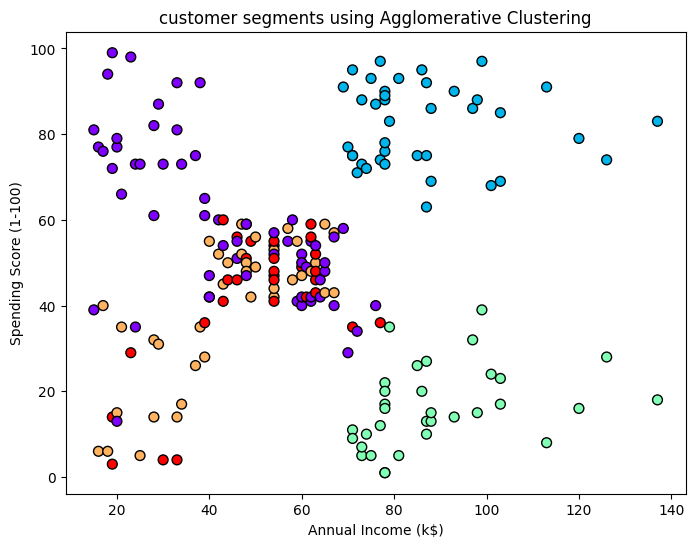

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(dfs['Annual Income (k$)'],
            dfs['Spending Score (1-100)'],
            c=dfs['Agglomerative_Cluster'],
            cmap='rainbow',s=50,edgecolors='k')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('customer segments using Agglomerative Clustering')
plt.show()

A Dendrogrm is a tree-like diagram (a graph that looks like a tree).

Its alike we using the Elbow methd in K-means to find the optimal K, we use a Dendrogram in Hierarcial clustering to find the optimal K (to determine how many clusters to split).

when you look at that tree graph , it clearly shows at which level cutting the linies vertically will give you a good separation ( clusters)


--- Generating Dendrogram for Hierarchical Clustering ---


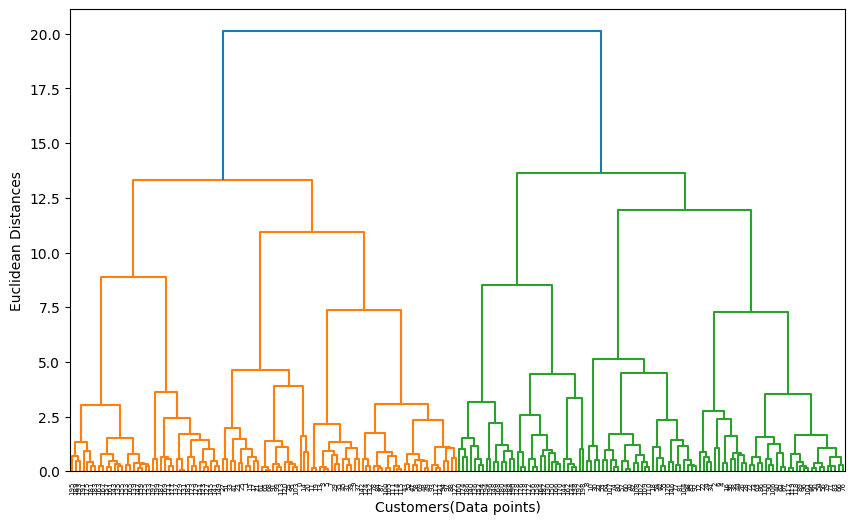

In [ ]:
print('\n--- Generating Dendrogram for Hierarchical Clustering ---')
plt.figure(figsize=(10, 6))
linked = sch.linkage(X_scaled, method='ward')
dendrogram = sch.dendrogram(linked)
plt.xlabel('Customers(Data points)')
plt.ylabel('Euclidean Distances')
plt.show()

In [ ]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans.labels_)
agg_silhouette = silhouette_score(X_scaled, agg_clusters)

print(f'K-means Silhouette Score: {kmeans_silhouette:.4f}')
print(f'Agglomerative Silhouette Score: {agg_silhouette:.4f}')

K-means Silhouette Score: 0.3144
Agglomerative Silhouette Score: 0.2870
